In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
import re
import scipy.signal as signal
from scipy import sparse
from scipy.sparse.linalg import spsolve
from matplotlib.ticker import MultipleLocator

# from lmfit.models import GaussianModel, LorentzianModel, PseudoVoigtModel

import plotly.graph_objects as go
from plotly.subplots import make_subplots

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Latin Modern Roman"],  # must be installed on your system
    "mathtext.fontset": "cm",             # Computer Modern math, matches LaTeX style
    "text.usetex": True,                    # render text via LaTeX
    "text.latex.preamble": r"\usepackage{amsmath, amssymb}"
})

In [2]:
def baseline_als(y, lam=1e5, p=0.001, niter=10):
    L = len(y)
    D = sparse.diags([1,-2,1],[0,-1,-2], shape=(L,L-2), dtype=None)
    w = np.ones(L)
    for i in range(niter):
        W = sparse.spdiags(w,0,L,L)
        Z = W + lam * D.dot(D.transpose())
        z = spsolve(Z, w*y)
        w = p * (y > z) + (1-p) * (y < z)
    return z

In [ ]:
# data.to_csv(r"../Data/Raman/NiGe/as-deposited.csv", sep=';')
# data.to_csv(os.path.join(os.path.dirname(file_path), '900_50-850cm-1.csv'), sep=';')

In [74]:
# file_path = r"../Data/Raman/NiGe/NiGe_900_B3_50%_100x_60sx10_01.txt"
file_path = r"../Data/Raman/NiGe/NiGe_850_B2_50%_100x_60sx10_01.txt"

data = pd.read_csv(file_path, skiprows=45, encoding='utf-8', delimiter='\t', header=None, names=['Raman shift', 'Intensity'])
data['Baseline'] = baseline_als(data['Intensity'], lam=1e6)
data['Corrected Intensity'] = data['Intensity'] - data['Baseline']
print(data.info())


file_path_as_dep = r"../Data/Raman/NiGe/NiGe_as-dep_50%_100x_60sx10_01.txt"
as_dep = pd.read_csv(file_path_as_dep, skiprows=45, encoding='utf-8', delimiter='\t', header=None, names=['Raman shift', 'Intensity'])

as_dep['Baseline'] = baseline_als(as_dep['Intensity'], lam=1e6)
as_dep['Corrected Intensity'] = as_dep['Intensity'] - as_dep['Baseline']
print(as_dep.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 934 entries, 0 to 933
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Raman shift          934 non-null    float64
 1   Intensity            934 non-null    float64
 2   Baseline             934 non-null    float64
 3   Corrected Intensity  934 non-null    float64
dtypes: float64(4)
memory usage: 29.3 KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 934 entries, 0 to 933
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Raman shift          934 non-null    float64
 1   Intensity            934 non-null    float64
 2   Baseline             934 non-null    float64
 3   Corrected Intensity  934 non-null    float64
dtypes: float64(4)
memory usage: 29.3 KB
None


C:\Users\lhage\AppData\Local\Temp\ipykernel_13196\1990753064.py:8: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  z = spsolve(Z, w*y)
C:\Users\lhage\AppData\Local\Temp\ipykernel_13196\1990753064.py:8: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  z = spsolve(Z, w*y)


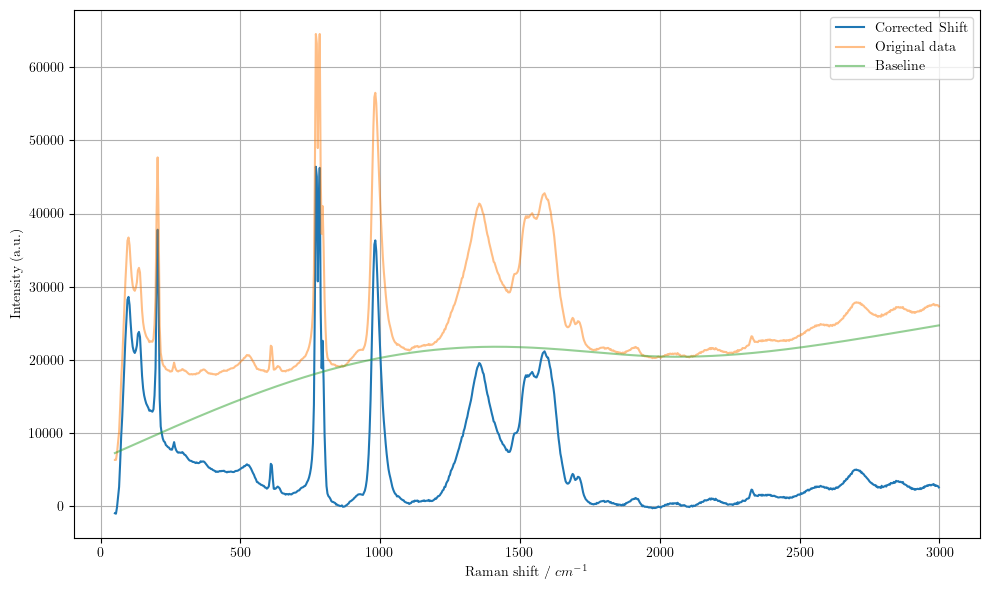

In [68]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(data['Raman shift'], data['Corrected Intensity'], label=f'Corrected Shift')
ax.plot(data['Raman shift'], data['Intensity'], label=f'Original data', alpha=0.5)
ax.plot(data['Raman shift'], data['Baseline'], label=f'Baseline', alpha=0.5)

# plt.vlines(peaks, ymin=0, ymax=data[data['Raman shift'].isin(peaks)]['Corrected Intensity'].values, color='red', linestyle='--', label='Peaks')


# ax.axes.get_yaxis().set_ticklabels([])
plt.xlabel("Raman shift / $cm^{-1}$")
plt.ylabel("Intensity (a.u.)")
plt.legend()
plt.tight_layout()
plt.grid(True)
# plt.savefig(f'../Images/{name}.pdf', dpi=500)
plt.show()

In [69]:
data = data[data['Raman shift'].between(900, 1800)]
as_dep = as_dep[as_dep['Raman shift'].between(900, 1800)]

data['intensity_norm'] = data['Corrected Intensity'] / data['Corrected Intensity'].max()
as_dep['intensity_norm'] = as_dep['Corrected Intensity'] / as_dep['Corrected Intensity'].max()

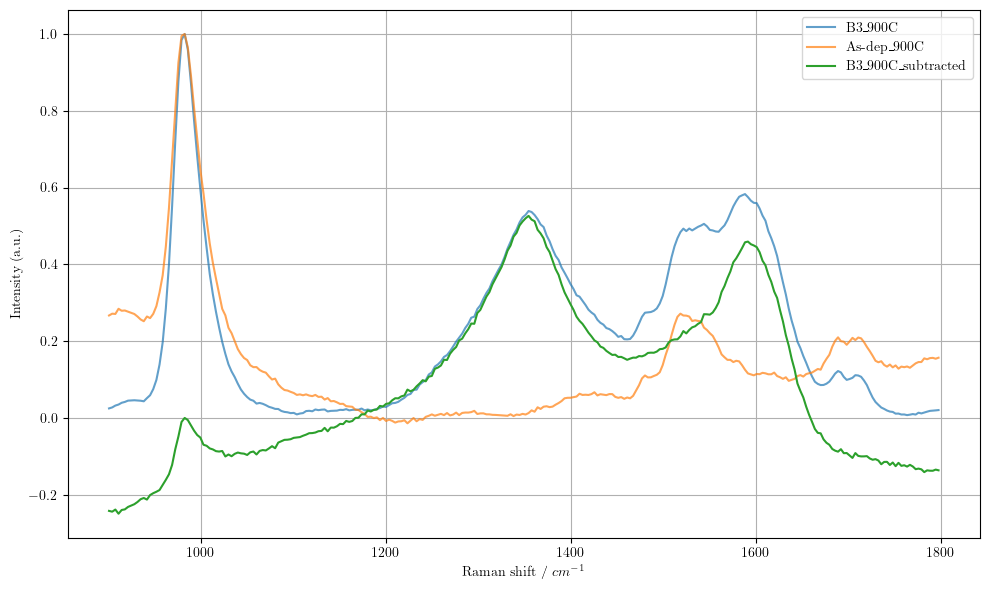

In [70]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(data['Raman shift'], data['intensity_norm'], label=f'B3_900C', alpha=0.7)
ax.plot(as_dep['Raman shift'], as_dep['intensity_norm'], label=f'As-dep_900C', alpha=0.7)
ax.plot(as_dep['Raman shift'], (data['intensity_norm'] - as_dep['intensity_norm']), label=f'B3_900C_subtracted', alpha=1)


# ax.axes.get_yaxis().set_ticklabels([])
plt.xlabel("Raman shift / $cm^{-1}$")
plt.ylabel("Intensity (a.u.)")
plt.legend()
plt.tight_layout()
plt.grid(True)
# plt.savefig(f'../Images/{name}.pdf', dpi=500)
plt.show()

In [71]:
subtracted = data.copy()
subtracted['intensity_sub'] = data['intensity_norm'].values - as_dep['intensity_norm'].values

# 2. Linear baseline on ROI (1200–1800 cm⁻¹)
#    Anchor points: mean of small windows at each edge (more robust than single point)
roi = subtracted[subtracted['Raman shift'].between(1100, 1800)].copy()

left_val  = roi[roi['Raman shift'].between(1100, 1230)]['intensity_sub'].mean()
right_val = roi[roi['Raman shift'].between(1770, 1800)]['intensity_sub'].mean()
left_x    = 1150   # midpoint of left window
right_x   = 1785   # midpoint of right window

# Linear interpolation between anchors
slope     = (right_val - left_val) / (right_x - left_x)
roi['linear_baseline'] = left_val + slope * (roi['Raman shift'] - left_x)
roi['intensity_final'] = roi['intensity_sub'] - roi['linear_baseline']

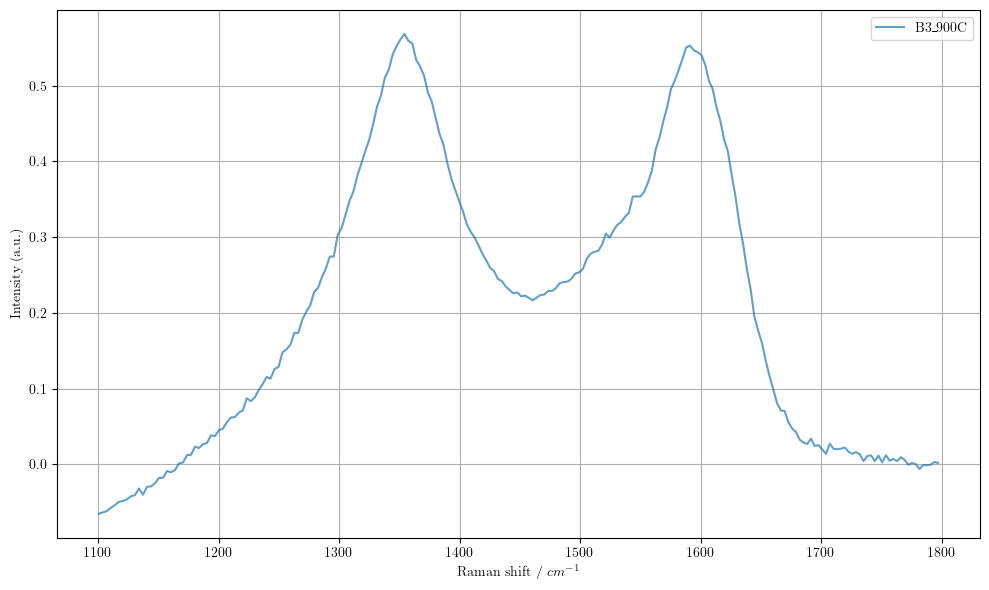

In [72]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(roi['Raman shift'], roi['intensity_final'], label=f'B3_900C', alpha=0.7)

plt.xlabel("Raman shift / $cm^{-1}$")
plt.ylabel("Intensity (a.u.)")
plt.legend()
plt.tight_layout()
plt.grid(True)
# plt.savefig(f'../Images/{name}.pdf', dpi=500)
plt.show()

In [ ]:
# roi.to_csv(r"../Data/Raman/NiGe/B2_850C_carbons.csv", sep=';')

### Ich fitte mir die Welt wie sie mir gefällt

- D band (~1350): Structural defects.
- G band (~1580): In-plane vibration of $sp^2$ atoms.
- D' band (~1620): Often appears as a shoulder on the G band in defective graphene.
- A or D'' band (~1500): Amorphous carbon/interstitial defects. This is that "hump" between the D and G peaks.

| Peak Name | Approx. Position (cm−1) | Physical Origin |
|-------|-------|-------|
| G | ~1580 | Ideal $sp^2$ Graphite lattice |
| D1 (D) | ~1350 | Disordered $sp^2$ (Edges/Defects) |
| D2 (D') | ~1620 | Disordered $sp^2$ (Shoulder on G) |
| D3 (A) | ~1500 | Amorphous carbon ($sp^3$ content) |
| D4 | ~1200 | Disordered $sp^2-sp^3$ polyenes |

In [3]:
file_path_850 = r"../Data/Raman/NiGe/NiGe_850_B2_50%_100x_60sx10_01.txt"

data_850 = pd.read_csv(file_path_850, skiprows=45, encoding='utf-8', delimiter='\t', header=None, names=['Raman shift', 'Intensity'])
data_850['Baseline'] = baseline_als(data_850['Intensity'], lam=1e6)
data_850['Corrected Intensity'] = data_850['Intensity'] - data_850['Baseline']

file_path_900 = r"../Data/Raman/NiGe/NiGe_900_B3_50%_100x_60sx10_01.txt"
data_900 = pd.read_csv(file_path_900, skiprows=45, encoding='utf-8', delimiter='\t', header=None, names=['Raman shift', 'Intensity'])
data_900['Baseline'] = baseline_als(data_900['Intensity'], lam=1e6)
data_900['Corrected Intensity'] = data_900['Intensity'] - data_900['Baseline']

file_path_as_dep = r"../Data/Raman/NiGe/NiGe_as-dep_50%_100x_60sx10_01.txt"
as_dep = pd.read_csv(file_path_as_dep, skiprows=45, encoding='utf-8', delimiter='\t', header=None, names=['Raman shift', 'Intensity'])
as_dep['Baseline'] = baseline_als(as_dep['Intensity'], lam=1e6)
as_dep['Corrected Intensity'] = as_dep['Intensity'] - as_dep['Baseline']


data_850['intensity_norm'] = data_850['Corrected Intensity'] / data_850.loc[data_850['Raman shift'].between(150, 250), 'Corrected Intensity'].max()
data_900['intensity_norm'] = data_900['Corrected Intensity'] / data_900.loc[data_900['Raman shift'].between(150, 250), 'Corrected Intensity'].max()
as_dep['intensity_norm'] = as_dep['Corrected Intensity'] / as_dep.loc[as_dep['Raman shift'].between(150, 250), 'Corrected Intensity'].max()

C:\Users\lhage\AppData\Local\Temp\ipykernel_25300\729212169.py:8: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  z = spsolve(Z, w*y)
C:\Users\lhage\AppData\Local\Temp\ipykernel_25300\729212169.py:8: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  z = spsolve(Z, w*y)
C:\Users\lhage\AppData\Local\Temp\ipykernel_25300\729212169.py:8: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  z = spsolve(Z, w*y)


In [4]:
peaks_idx_850, _ = signal.find_peaks(data_850['intensity_norm'], prominence=0.02, width=1)
peaks_850 = data_850.loc[peaks_idx_850, 'Raman shift']

peaks_idx_900, _ = signal.find_peaks(data_900['intensity_norm'], prominence=0.02, width=1)
peaks_900 = data_900.loc[peaks_idx_900, 'Raman shift']

print(peaks_850)
print(peaks_900)

13      100.091
23      137.390
41      204.151
57      263.089
129     523.697
153     608.924
199     770.045
203     783.920
261     982.682
373    1354.170
446    1587.950
478    1688.430
551    1913.250
642    2185.220
691    2328.000
824    2703.210
876    2845.210
Name: Raman shift, dtype: float64
12       96.3525
41      204.1510
153     608.9240
199     770.0450
260     979.2940
373    1354.1700
445    1584.7900
513    1796.9800
550    1910.2100
593    2039.8900
642    2185.2200
692    2330.8800
823    2700.4600
876    2845.2100
Name: Raman shift, dtype: float64


137.39 $Ni_2Si$
204.151 $SiC$
263.089 $NiSi$


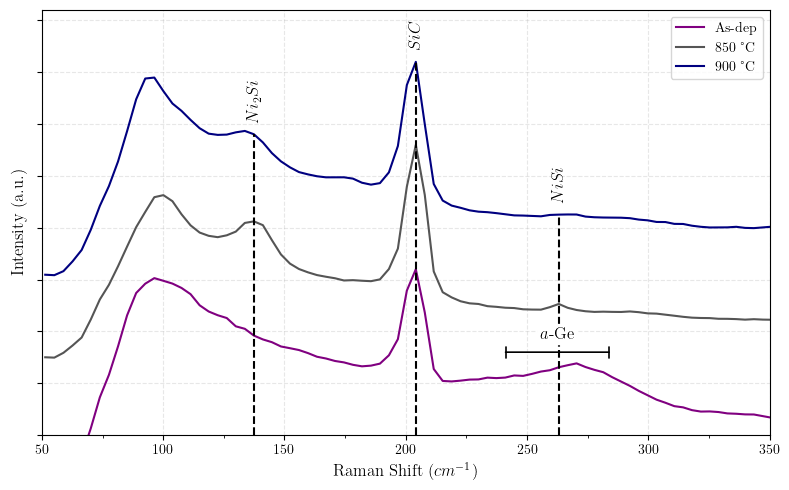

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(as_dep['Raman shift'], as_dep["intensity_norm"] - 0.2, color="#800080", label='As-dep')
ax.plot(data_850['Raman shift'], data_850["intensity_norm"] + 0.4, color="#555555", label='850 °C')
ax.plot(data_900['Raman shift'], data_900["intensity_norm"] + 0.8, color="#000080", label='900 °C')

# plt.vlines(peaks_850, ymin=0, ymax=data_850[data_850['Raman shift'].isin(peaks_850)]['intensity_norm'].values, color='red', linestyle='--', label='Peaks')

# ax.vlines([1352.5, 1583], ymin=0, ymax=1.8, color="#555555", linestyle='--')
# peak_labels = {96.3546: '$Ni_2Si$', 137.8: '$Ni_2Si$', 181: '$Ni_2Si$', 212: '$NiSi$', 363: '$NiSi$'}
peak_labels = {137.390: '$Ni_2Si$', 204.151: '$SiC$',  263.089: '$NiSi$'}

for position, name in peak_labels.items():
    print(position, name)
    y_height = np.interp(position, data_900['Raman shift'], data_900['intensity_norm'])
    ax.vlines([position], ymin=0, ymax=y_height + 0.8, color="#000000", linestyle='--')
    plt.text(position, y_height + 0.8 + 0.05, name, 
            ha='center', va='bottom', fontsize=12, fontweight='bold', rotation=90)
    

def annotate_region(ax, x1, x2, y, label, color='black', fs=12):
    """Clean bracket: horizontal bar + end ticks + centered label"""
    tick_h = (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.01  # 1% of y range

    ax.annotate('', 
                xy=(x2, y), xytext=(x1, y),
                arrowprops=dict(arrowstyle='|-|',
                                color=color,
                                lw=1.2,
                                mutation_scale=4))
    ax.text((x1 + x2) / 2, y + tick_h * 1.5, label,
            ha='center', va='bottom', fontsize=fs,
            color=color, fontstyle='italic',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='none'))

# Usage
annotate_region(ax, x1=240, x2=285, 
                y=0.4,
                label=r'$a$-Ge')


ax.set_xlabel(r"Raman Shift ($cm^{-1}$)", fontsize=12)
ax.set_ylabel(r"Intensity (a.u.)", fontsize=12)
ax.set_yticklabels([])
ax.set_xlim(50, 350)
ax.set_ylim(0, 2.05)
ax.xaxis.set_minor_locator(MultipleLocator(25))
ax.grid(True, linestyle='--', alpha=0.3, zorder=1)
plt.legend()
plt.tight_layout()
# plt.savefig(f'../Images/Raman/NiGe/Raman_NiGe_NiSi.pdf', dpi=300)
plt.show()